# Seoul Bike Usage Data Analysis

서울 공공자전거 (따릉이) 이용 데이터를 활용하여 자전거 이용 패턴을 분석하는 프로젝트이다.

시간대, 요일, 기온, 습도와 같은 요인이 자전거 이용량에 어떤 영향을 미치는지
탐색적 데이터 분석(EDA)을 통해 확인하고자 한다.

## 프로젝트 목적

본 프로젝트에서는 공공 자전거 이용 데이터를 분석하여
시간적 요인과 날씨 요인이 자전거 이용량에 미치는 영향을 파악하고자 한다.

이를 통해 자전거 이용 패턴을 이해하고
데이터 기반으로 의미 있는 인사이트를 도출하는 것을 목표로 한다.

In [32]:
!pip install pandas
!pip install matplotlib

You should consider upgrading via the 'c:\users\서지현\appdata\local\programs\python\python39\python.exe -m pip install --upgrade pip' command.


You should consider upgrading via the 'c:\users\서지현\appdata\local\programs\python\python39\python.exe -m pip install --upgrade pip' command.


## 데이터 소개

본 데이터셋은 자전거 대여량과 기상 정보를 포함하고 있다.

분석에 사용한 주요 변수는 다음과 같다.

- datetime : 날짜 및 시간
- temperature : 기온
- humidity : 습도
- windspeed : 풍속
- precipitation : 강수량
- count : 자전거 대여 수
- weekday : 요일 정보

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/Seoul_public_bike_data.csv")
df.head()

,ID,datetime,temperature,precipitation,windspeed,humidity,dew_point,sunshine,solar_radiation,snowfall,cloud_cover,visibility,ground_temp,weekday,holiday,count
0,1,2015-09-19 00:00:00,20.2,0.0,0.8,60.0,12.1,0.0,0.00,0.0,4.0,2000.0,19.1,Saturday,0,1
1,2,2015-09-19 01:00:00,19.5,0.0,1.2,63.0,12.2,0.0,0.00,0.0,NaN,2000.0,18.3,Saturday,0,2
2,3,2015-09-19 07:00:00,17.2,0.0,2.0,75.0,12.7,0.3,0.09,0.0,3.0,2000.0,17.0,Saturday,0,1
3,4,2015-09-19 08:00:00,19.2,0.0,1.9,63.0,11.9,1.0,0.55,0.0,4.0,1800.0,19.7,Saturday,0,2
4,5,2015-09-19 09:00:00,21.1,0.0,1.0,57.0,12.2,1.0,1.12,0.0,4.0,1800.0,25.3,Saturday,0,21


## 데이터 탐색

데이터의 구조와 변수 구성을 확인하기 위해
데이터의 일부와 컬럼 정보를 확인한다.

In [34]:
df.head()
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81018 entries, 0 to 81017
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               81018 non-null  int64  
 1   datetime         81018 non-null  object 
 2   temperature      81013 non-null  float64
 3   precipitation    78612 non-null  float64
 4   windspeed        80895 non-null  float64
 5   humidity         81014 non-null  float64
 6   dew_point        81016 non-null  float64
 7   sunshine         79224 non-null  float64
 8   solar_radiation  79222 non-null  float64
 9   snowfall         72051 non-null  float64
 10  cloud_cover      75536 non-null  float64
 11  visibility       81017 non-null  float64
 12  ground_temp      80986 non-null  float64
 13  weekday          81018 non-null  object 
 14  holiday          81018 non-null  int64  
 15  count            81018 non-null  int64  
dtypes: float64(11), int64(3), object(2)
memory usage: 9.9+ MB


,ID,temperature,precipitation,windspeed,humidity,dew_point,sunshine,solar_radiation,snowfall,cloud_cover,visibility,ground_temp,holiday,count
count,81018.000000,81013.000000,78612.000000,80895.000000,81014.000000,81016.000000,79224.000000,79222.000000,72051.000000,75536.000000,81017.000000,80986.000000,81018.000000,81018.000000
mean,40509.500000,13.494610,0.151235,2.206920,61.884938,5.601028,0.279068,0.581809,0.077935,4.903463,1650.038560,14.925419,0.049187,2418.815078
std,23388.026392,11.025119,1.238787,1.158228,19.641982,12.190164,0.416382,0.868521,0.694107,4.013494,756.219163,13.224631,0.216259,3201.823068
min,1.000000,-18.500000,0.000000,0.000000,7.000000,-31.100000,0.000000,0.000000,0.000000,0.000000,14.000000,-13.600000,0.000000,1.000000
25%,20255.250000,4.500000,0.000000,1.400000,47.000000,-3.700000,0.000000,0.000000,0.000000,0.000000,1126.000000,3.200000,0.000000,268.000000
50%,40509.500000,14.500000,0.000000,2.100000,62.000000,6.300000,0.000000,0.030000,0.000000,6.000000,1941.000000,14.600000,0.000000,1064.000000
75%,60763.750000,22.900000,0.000000,2.900000,78.000000,16.100000,0.700000,0.960000,0.000000,9.000000,2000.000000,24.300000,0.000000,3377.000000
max,81018.000000,39.400000,64.700000,8.800000,100.000000,27.900000,1.000000,3.810000,28.600000,10.000000,5000.000000,65.100000,1.000000,23761.000000


## 데이터 전처리

datetime 변수는 문자열 형태로 저장되어 있기 때문에
분석에 활용하기 위해 datetime 형식으로 변환하였다.

또한 시간대별 분석을 위해 hour 변수를 생성하였다.

In [35]:
df["datetime"] = pd.to_datetime(df["datetime"])
df["month"] = df["datetime"].dt.month
df["hour"] = df["datetime"].dt.hour

## 월별 자전거 이용량 분석

자전거 이용량이 월별로 어떻게 변화하는지 확인하기 위해
월(month) 기준 평균 이용량을 분석하였다.

이를 통해 계절에 따른 자전거 이용 패턴을 파악할 수 있다.

In [36]:
monthly_usage = df.groupby("month")["count"].sum()

monthly_usage

month
1      6746998
2      7820194
3     13840745
4     18834643
5     21689371
6     22220234
7     19566870
8     18046806
9     21156103
10    21594275
11    15316300
12     9135021
Name: count, dtype: int64

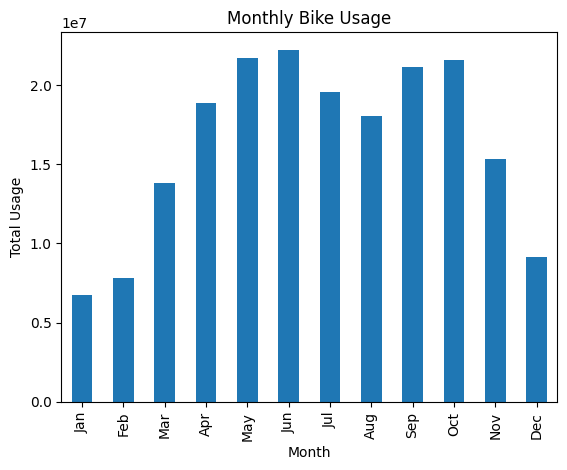

In [37]:
import matplotlib.pyplot as plt

month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

monthly_usage.index = month_names[:len(monthly_usage)]

monthly_usage.plot(kind="bar")

plt.title("Monthly Bike Usage")
plt.xlabel("Month")
plt.ylabel("Total Usage")

plt.savefig("../images/monthly_usage.png") 

plt.show()

### 분석 결과

월별 자전거 이용량을 분석한 결과 계절에 따라 이용량이 변화하는 패턴을 확인할 수 있었다.

일반적으로 기온이 높은 봄과 여름에 이용량이 증가하고
기온이 낮은 겨울에는 이용량이 감소하는 경향이 나타났다.

이는 날씨가 따뜻할수록 야외 활동이 증가하기 때문으로 해석할 수 있다.

## 시간대별 자전거 이용량 분석

시간대에 따라 자전거 이용량이 어떻게 변화하는지 확인하기 위해
시간(hour) 기준 평균 이용량을 계산하였다.

In [38]:
hourly_usage = df.groupby("hour")["count"].mean()

hourly_usage

hour
0     1355.116307
1      957.645536
2      638.314533
3      431.638698
4      328.191732
5      494.360261
6     1032.254745
7     2477.198462
8     3880.343584
9     2298.575820
10    1882.049040
11    2186.574594
12    2473.602246
13    2530.373818
14    2648.102541
15    2975.132939
16    3578.308693
17    4624.335995
18    5803.522317
19    4105.360035
20    3517.469249
21    3257.537733
22    2743.393132
23    1746.255841
Name: count, dtype: float64

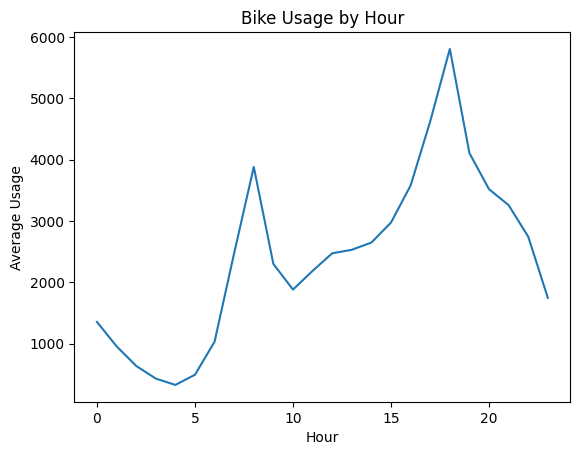

In [39]:
import matplotlib.pyplot as plt

hourly_usage.plot()

plt.title("Bike Usage by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Usage")

plt.savefig("../images/hourly_usage.png") 

plt.show()

### 분석 결과

분석 결과 출퇴근 시간대에 자전거 이용량이 증가하는 패턴을 확인할 수 있었다.

특히 오전 출근 시간과 저녁 퇴근 시간에 이용량이 증가하는 경향이 나타났다.

## 요일별 자전거 이용량 분석

요일에 따라 자전거 이용 패턴이 어떻게 달라지는지 확인하기 위해
요일별 평균 이용량을 분석하였다.

In [40]:
weekday_usage = df.groupby("weekday")["count"].mean()

weekday_usage

weekday
Friday       2627.608681
Monday       2447.553006
Saturday     2227.077882
Sunday       2032.885497
Thursday     2550.331572
Tuesday      2488.402516
Wednesday    2558.830780
Name: count, dtype: float64

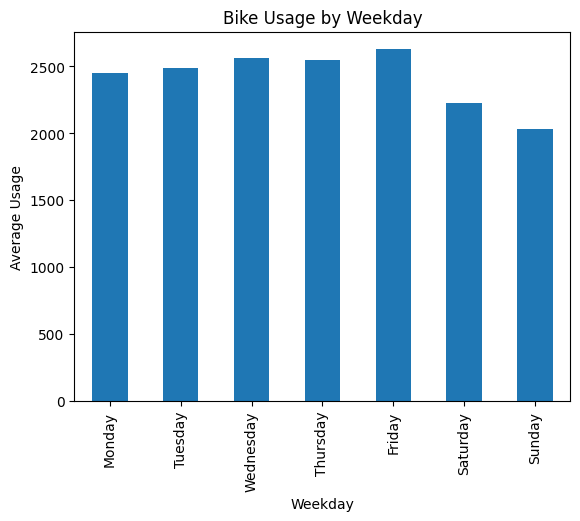

In [41]:
import matplotlib.pyplot as plt

order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

weekday_usage = weekday_usage.reindex(order)

weekday_usage.plot(kind="bar")

plt.title("Bike Usage by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Usage")

plt.savefig("../images/weekday_usage.png") 

plt.show()

### 분석 결과

분석 결과 평일에 자전거 이용량이 더 높은 경향을 확인할 수 있었다.

이는 자전거가 출퇴근 및 이동 수단으로 활용되는 경우가 많기 때문으로
해석할 수 있다.

## 온도와 자전거 이용량 관계

기온이 자전거 이용량에 어떤 영향을 미치는지 확인하기 위해
온도와 이용량 간의 관계를 산점도를 통해 분석하였다.

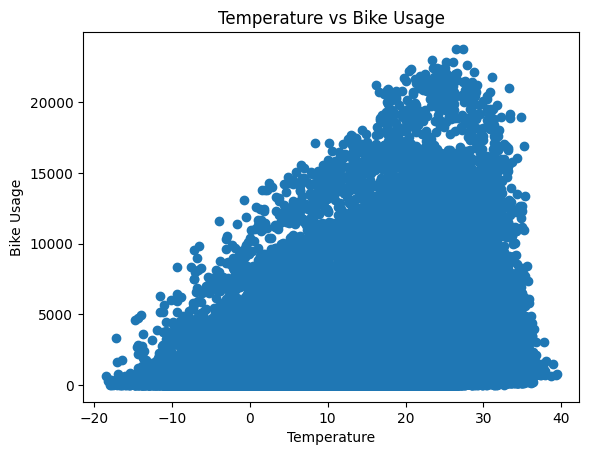

In [42]:
import matplotlib.pyplot as plt

plt.scatter(df["temperature"], df["count"])

plt.xlabel("Temperature")
plt.ylabel("Bike Usage")
plt.title("Temperature vs Bike Usage")

plt.savefig("../images/temperature_usage.png") 

plt.show()

### 분석 결과

기온이 높아질수록 자전거 이용량이 증가하는 경향을 확인할 수 있었다.

이는 날씨가 따뜻할수록 자전거 이용이 증가하기 때문으로 해석할 수 있다.

## 습도와 자전거 이용량 관계

습도가 자전거 이용량에 미치는 영향을 확인하기 위해
습도와 이용량 간의 관계를 분석하였다.

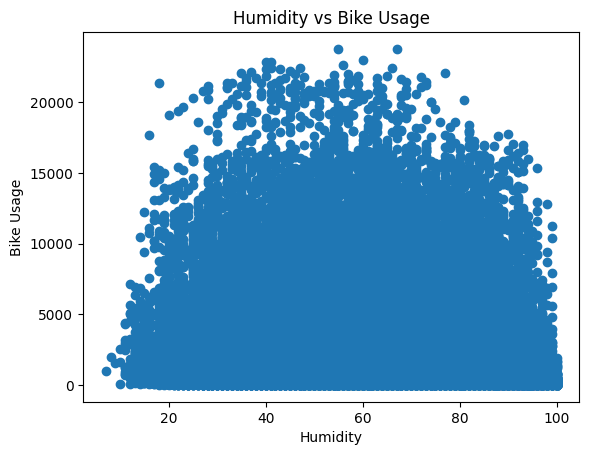

In [43]:
import matplotlib.pyplot as plt

plt.scatter(df["humidity"], df["count"])

plt.xlabel("Humidity")
plt.ylabel("Bike Usage")
plt.title("Humidity vs Bike Usage")

plt.savefig("../images/humidity_usage.png") 

plt.show()

## 습도와 자전거 이용량 관계

습도가 자전거 이용량에 미치는 영향을 확인하기 위해
습도와 이용량 간의 관계를 분석하였다.

## 변수 간 상관관계 분석

각 변수 간 관계를 파악하기 위해 상관관계 분석을 수행하였다.
상관관계 히트맵을 통해 변수 간 관계를 시각적으로 확인하였다.

In [44]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

numeric_df.head()

corr = numeric_df.corr()

corr

,ID,temperature,precipitation,windspeed,humidity,dew_point,sunshine,solar_radiation,snowfall,cloud_cover,visibility,ground_temp,holiday,count
ID,1.000000,0.071614,0.022163,0.052542,0.172283,0.135576,-0.039359,0.033094,0.061314,-0.009751,0.320245,0.038693,-0.002939,0.547978
temperature,0.071614,1.000000,0.062285,0.006482,0.164449,0.908018,0.142267,0.306184,-0.210013,0.265640,0.008404,0.924021,-0.004332,0.322667
precipitation,0.022163,0.062285,1.000000,0.053823,0.202179,0.126471,-0.081091,-0.068987,0.033546,0.156470,-0.164790,0.039223,0.006179,-0.075971
windspeed,0.052542,0.006482,0.053823,1.000000,-0.211163,-0.089265,0.255938,0.271713,0.014422,0.019092,0.159181,0.104024,-0.000517,0.119391
humidity,0.172283,0.164449,0.202179,-0.211163,1.000000,0.554474,-0.531820,-0.469187,0.068723,0.391993,-0.383686,-0.000482,-0.002591,-0.100532
dew_point,0.135576,0.908018,0.126471,-0.089265,0.554474,1.000000,-0.111386,0.051031,-0.149302,0.382710,-0.134687,0.769546,-0.005235,0.235695
sunshine,-0.039359,0.142267,-0.081091,0.255938,-0.531820,-0.111386,1.000000,0.819240,-0.031786,-0.358667,0.141995,0.362019,-0.005126,0.190045
solar_radiation,0.033094,0.306184,-0.068987,0.271713,-0.469187,0.051031,0.819240,1.000000,-0.044029,-0.166585,0.136551,0.581520,-0.007199,0.211473
snowfall,0.061314,-0.210013,0.033546,0.014422,0.068723,-0.149302,-0.031786,-0.044029,1.000000,0.009323,-0.035804,-0.162604,-0.005057,-0.055729
cloud_cover,-0.009751,0.265640,0.156470,0.019092,0.391993,0.382710,-0.358667,-0.166585,0.009323,1.000000,-0.219522,0.185912,0.017507,-0.054188


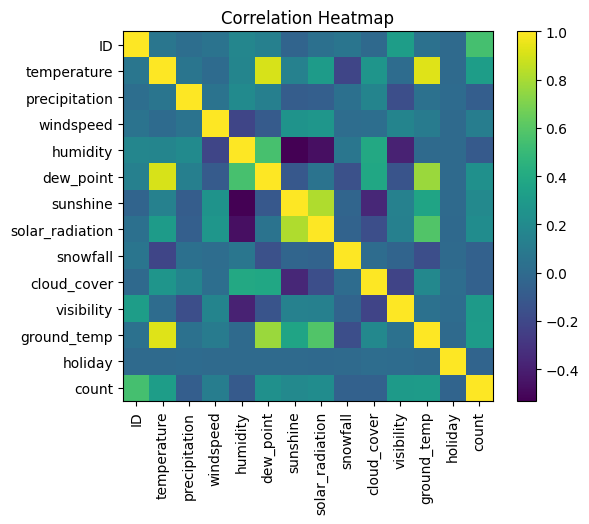

In [45]:
import matplotlib.pyplot as plt

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.savefig("../images/correlation_heatmap.png") 

plt.show()

### 분석 결과

기온과 자전거 이용량 사이에 양의 상관관계가 나타났다.
반면 습도는 자전거 이용량과 약한 음의 상관관계를 보였다.

## 최종 결론 (Conclusion)

본 프로젝트에서는 서울 공공자전거 이용 데이터를 활용하여
시간, 요일, 날씨 요인이 자전거 이용량에 미치는 영향을 분석하였다.

분석 결과 다음과 같은 주요 패턴을 확인할 수 있었다.

1. 자전거 이용량은 출퇴근 시간대에 증가하는 패턴을 보였다.
2. 기온이 높을수록 자전거 이용량이 증가하는 경향이 나타났다.
3. 습도가 높을 경우 자전거 이용량이 다소 감소하는 경향이 나타났다.
4. 평일에는 출퇴근 목적의 이용이 많아 주말보다 이용량이 높게 나타났다.

이러한 분석 결과를 통해 시간적 요인과 날씨 요인이
공공 자전거 이용 패턴에 영향을 미친다는 것을 확인할 수 있었다.

## Bike Rental Prediction Model

앞선 분석에서 시간대, 온도, 요일 등이 자전거 대여량에 영향을 미치는 주요 변수라는 것을 확인하였다.  
이러한 변수들을 기반으로 자전거 대여량을 예측하기 위해 머신러닝 모델을 적용하였다.

본 분석에서는 RandomForest 회귀 모델을 사용하여 대여량을 예측하고 모델 성능을 평가하였다.

In [46]:
!pip install scikit-learn

You should consider upgrading via the 'c:\users\서지현\appdata\local\programs\python\python39\python.exe -m pip install --upgrade pip' command.


In [47]:
df["datetime"] = pd.to_datetime(df["datetime"])

df["hour"] = df["datetime"].dt.hour
df["month"] = df["datetime"].dt.month

In [48]:
features = [
    "temperature",
    "humidity",
    "windspeed",
    "hour",
    "month",
    "weekday"
]

weekday_map = {
    "Monday":0,
    "Tuesday":1,
    "Wednesday":2,
    "Thursday":3,
    "Friday":4,
    "Saturday":5,
    "Sunday":6
}

df["weekday"] = df["weekday"].map(weekday_map)

X = df[features]
y = df["count"]

### Train / Test Split

모델 학습과 평가를 위해 데이터를 학습 데이터와 테스트 데이터로 분리하였다.

- Train data : 모델 학습
- Test data : 모델 성능 평가

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Model Training

RandomForestRegressor 모델을 사용하여 자전거 대여량을 예측하였다.

RandomForest는 여러 개의 의사결정 트리를 기반으로 예측을 수행하는 앙상블 모델로  
비선형 관계를 잘 학습할 수 있는 특징이 있다.

In [50]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)

RandomForestRegressor()

### Prediction

학습된 모델을 활용하여 테스트 데이터에 대한 자전거 대여량을 예측하였다.

In [51]:
pred = model.predict(X_test)

### Model Evaluation

모델 성능 평가는 MAE(Mean Absolute Error)를 사용하였다.

MAE는 실제 값과 예측 값 사이의 평균 절대 오차를 의미하며  
값이 작을수록 모델의 예측 성능이 좋음을 의미한다.

In [52]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, pred)

print("MAE:", mae)

MAE: 1684.036912665597


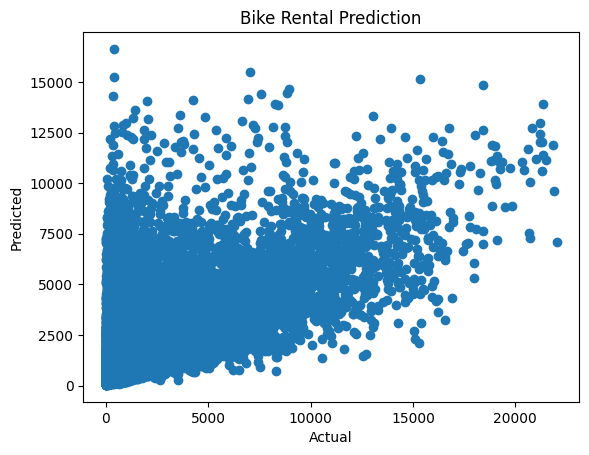

In [53]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Bike Rental Prediction")

plt.show()

### Feature Importance

RandomForest 모델을 통해 각 변수의 중요도를 확인하였다.

이를 통해 자전거 대여량 예측에 영향을 미치는 주요 변수를 파악할 수 있다.

In [54]:
importance = model.feature_importances_

feature_importance = pd.Series(importance, index=X.columns)

feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance)

temperature    0.282122
hour           0.224413
humidity       0.195968
windspeed      0.147102
weekday        0.086083
month          0.064312
dtype: float64


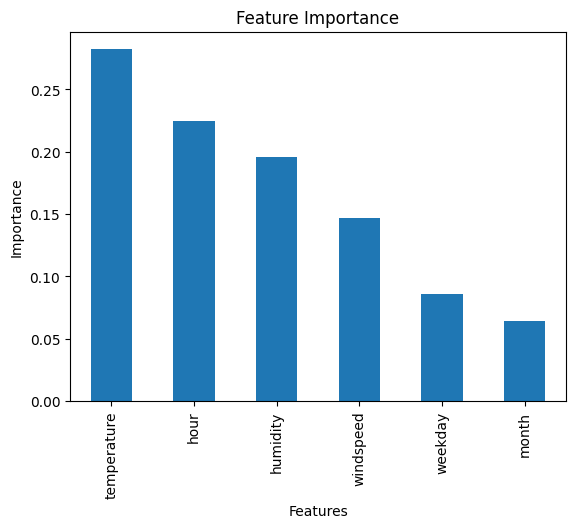

In [55]:
import matplotlib.pyplot as plt

feature_importance.plot(kind="bar")

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.savefig("../images/feature_importance.png")

plt.show()

## Final Conclusion

본 분석에서는 서울 공공자전거 데이터를 활용하여 자전거 이용 패턴을 분석하였다.

주요 분석 결과는 다음과 같다.

- 특정 시간대에 자전거 이용량이 집중되는 경향이 나타났다.
- 온도가 적절한 범위일 때 이용량이 증가하는 경향이 있었다.
- 요일에 따라 이용량 차이가 존재하였다.

또한 RandomForest 모델을 활용하여 자전거 대여량 예측을 수행하였으며  
변수 중요도 분석을 통해 시간대와 기온이 주요 예측 변수임을 확인하였다.

이러한 분석 결과는 공공자전거 운영 전략 수립에 활용될 수 있다.